# All-SCA PSF Validation

Comprehensive validation of PSF interpolation across all 18 Roman WFI detectors and both grism orders.

**Goal**: Verify that pre-cached PSF grids produce accurate interpolation across the full focal plane.

**Approach**:
1. Load pre-cached PSF payloads (36 files: 18 SCAs × 2 orders)
2. For each payload, run validation at 32 Sobol test points
3. Compare interpolated PSFs against direct STPSF calculations
4. Aggregate statistics and visualize results

**Validation Criteria**:
- Total flux error: <1%
- Radial fractional error: <10% at all radii

**Prerequisites**:
- Run `scripts/generate_psf_caches.py` to generate all cache files
- Cache directory: `data/psf_cache/`

## Setup

In [1]:
import logging
import time
import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import qmc
from tqdm import tqdm

import stpsf.roman

from roman_disperser import psf_model, psf_utils

# Suppress STPSF warnings
logging.getLogger('stpsf').setLevel(logging.ERROR)
logging.getLogger('poppy').setLevel(logging.ERROR)
warnings.filterwarnings('ignore', message='.*outside the range.*')
warnings.filterwarnings('ignore', message='.*Attempted to get aberrations.*')
warnings.filterwarnings('ignore', message='.*clipping to closest.*')

plt.rcParams['font.size'] = 11
plt.rcParams['figure.facecolor'] = 'white'

/Users/npadmana/10-Notebook/1-Projects/roman_disperser/.pixi/envs/default/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ============================================================================
# CONFIGURATION
# ============================================================================

# Cache directory
CACHE_DIR = Path('../../data/psf_cache')

# Detectors and orders to validate
DETECTORS = [f'WFI{i:02d}' for i in range(1, 19)]  # All 18 SCAs
ORDERS = ['0', '1']  # GRISM0 and GRISM1

# PSF parameters (must match cache files)
FOV_ARCSEC = 5.0
OVERSAMPLE = 4
PIXEL_SCALE = 0.11 / OVERSAMPLE  # oversampled pixel scale

# Test point configuration
N_TEST_POINTS = 32  # Reduced from 128 for faster validation
X_RANGE = (100.0, 3988.0)  # Avoid edges for STPSF stability
Y_RANGE = (100.0, 3988.0)
WL_RANGE = (0.95e-6, 1.95e-6)  # Slightly inside grid bounds

print("Configuration:")
print(f"  Cache directory: {CACHE_DIR.resolve()}")
print(f"  Detectors: {len(DETECTORS)} ({DETECTORS[0]} to {DETECTORS[-1]})")
print(f"  Orders: {ORDERS}")
print(f"  Test points per SCA/order: {N_TEST_POINTS}")
print(f"  Total validations: {len(DETECTORS) * len(ORDERS) * N_TEST_POINTS}")

Configuration:
  Cache directory: /Users/npadmana/10-Notebook/1-Projects/roman_disperser/data/psf_cache
  Detectors: 18 (WFI01 to WFI18)
  Orders: ['0', '1']
  Test points per SCA/order: 32
  Total validations: 1152


## Check Cache Files

In [3]:
# Check that all cache files exist
cache_files = list(CACHE_DIR.glob('psf_*.npz'))
print(f"Found {len(cache_files)} cache files in {CACHE_DIR}")

# Build expected file list
expected_files = []
missing_files = []
for det in DETECTORS:
    for order in ORDERS:
        filter_name = 'GRISM0' if order == '0' else 'GRISM1'
        pattern = f'psf_{det}_{filter_name}_4x4x56_*.npz'
        matches = list(CACHE_DIR.glob(pattern))
        if matches:
            expected_files.append(matches[0])
        else:
            missing_files.append((det, order))

if missing_files:
    print(f"\nMISSING CACHE FILES ({len(missing_files)}):")
    for det, order in missing_files:
        print(f"  {det} order {order}")
    print("\nRun: pixi run python scripts/generate_psf_caches.py")
else:
    print(f"\nAll {len(expected_files)} expected cache files found.")
    
# Show sample of files
print(f"\nSample cache files:")
for f in sorted(cache_files)[:4]:
    size_mb = f.stat().st_size / 1e6
    print(f"  {f.name} ({size_mb:.1f} MB)")

Found 36 cache files in ../../data/psf_cache

All 36 expected cache files found.

Sample cache files:
  psf_WFI01_GRISM0_4x4x56_0.90-2.00um_fov5.0_os4.npz (111.2 MB)
  psf_WFI01_GRISM1_4x4x56_0.90-2.00um_fov5.0_os4.npz (111.2 MB)
  psf_WFI02_GRISM0_4x4x56_0.90-2.00um_fov5.0_os4.npz (111.2 MB)
  psf_WFI02_GRISM1_4x4x56_0.90-2.00um_fov5.0_os4.npz (111.2 MB)


## Helper Functions

In [4]:
def generate_sobol_test_points(n_points, x_range, y_range, wl_range, seed=42):
    """
    Generate Sobol sequence test points in (x, y, wavelength) space.
    """
    sampler = qmc.Sobol(d=3, scramble=True, seed=seed)
    points = sampler.random(n_points)
    
    x_test = x_range[0] + points[:, 0] * (x_range[1] - x_range[0])
    y_test = y_range[0] + points[:, 1] * (y_range[1] - y_range[0])
    wl_test = wl_range[0] + points[:, 2] * (wl_range[1] - wl_range[0])
    
    return x_test, y_test, wl_test


def compute_direct_psf(wfi, xsca, ysca, wavelength, fov_arcsec, oversample):
    """
    Compute PSF directly from STPSF at given position and wavelength.
    """
    x_stpsf, y_stpsf = psf_utils.sca_to_stpsf_position(float(xsca), float(ysca))
    wfi.detector_position = (float(x_stpsf), float(y_stpsf))
    
    psf_hdu = wfi.calc_psf(
        monochromatic=float(wavelength),
        fov_arcsec=fov_arcsec,
        oversample=oversample
    )
    
    return psf_hdu['OVERDIST'].data


def compute_radial_bins(psf_shape, pixel_scale, bin_size, max_radius):
    """
    Compute radial bin indices for a PSF array.
    """
    ny, nx = psf_shape
    cy, cx = (ny - 1) / 2.0, (nx - 1) / 2.0
    
    y, x = np.mgrid[0:ny, 0:nx]
    r_arcsec = np.sqrt((x - cx)**2 + (y - cy)**2) * pixel_scale
    
    n_bins = int(np.ceil(max_radius / bin_size))
    bin_edges = np.linspace(0, max_radius, n_bins + 1)
    
    bin_indices = np.digitize(r_arcsec, bin_edges) - 1
    bin_indices[r_arcsec > max_radius] = -1
    
    return bin_indices, bin_edges


def compute_radial_mae(psf_interp, psf_direct, bin_indices, n_bins):
    """
    Compute mean absolute error and mean PSF value per radial bin.
    """
    abs_error = np.abs(np.asarray(psf_interp) - np.asarray(psf_direct))
    psf_direct_arr = np.asarray(psf_direct)

    mae_per_bin = np.zeros(n_bins)
    psf_per_bin = np.zeros(n_bins)

    for i in range(n_bins):
        mask = bin_indices == i
        if mask.sum() > 0:
            mae_per_bin[i] = abs_error[mask].mean()
            psf_per_bin[i] = psf_direct_arr[mask].mean()

    return mae_per_bin, psf_per_bin


# Radial analysis configuration
RADIAL_BIN_SIZE = 0.1  # arcsec
RADIAL_MAX = 2.0  # arcsec


def validate_single_payload(payload, detector, order, x_test, y_test, wl_test,
                           fov_arcsec, oversample, pixel_scale,
                           radial_bin_size, radial_max):
    """
    Validate a single PSF payload against direct STPSF calculations.
    Computes both flux errors and radial profile errors in one pass.
    
    Returns
    -------
    results : dict
        - 'flux_errors': array of fractional flux errors
        - 'mean_flux_error': mean flux error
        - 'max_flux_error': maximum flux error
        - 'interp_time': total interpolation time
        - 'direct_time': total direct STPSF time
        - 'mean_mae_per_bin': radial MAE averaged over test points
        - 'mean_psf_per_bin': radial PSF profile averaged over test points
        - 'bin_edges': radial bin edges
    """
    n_test = len(x_test)
    
    # Initialize STPSF
    filter_map = {'0': 'GRISM0', '1': 'GRISM1'}
    wfi = stpsf.roman.WFI()
    wfi.filter = filter_map[order]
    wfi.detector = detector
    
    flux_errors = []
    all_mae_per_bin = []
    all_psf_per_bin = []
    bin_indices = None
    bin_edges = None
    n_bins = None
    t_interp = 0
    t_direct = 0
    
    for i in range(n_test):
        x, y, wl = x_test[i], y_test[i], wl_test[i]
        
        # Interpolated PSF
        t0 = time.time()
        psf_interp = np.asarray(psf_model.interpolate_psf(payload, float(x), float(y), float(wl)))
        t_interp += time.time() - t0
        
        # Direct STPSF PSF
        t0 = time.time()
        psf_direct = compute_direct_psf(wfi, x, y, wl, fov_arcsec, oversample)
        t_direct += time.time() - t0
        
        # Initialize radial bins on first iteration
        if bin_indices is None:
            bin_indices, bin_edges = compute_radial_bins(
                psf_direct.shape, pixel_scale, radial_bin_size, radial_max
            )
            n_bins = len(bin_edges) - 1
        
        # Flux error
        flux_interp = psf_interp.sum()
        flux_direct = psf_direct.sum()
        flux_error = abs(flux_interp - flux_direct) / flux_direct
        flux_errors.append(flux_error)
        
        # Radial MAE
        mae_per_bin, psf_per_bin = compute_radial_mae(psf_interp, psf_direct, bin_indices, n_bins)
        all_mae_per_bin.append(mae_per_bin)
        all_psf_per_bin.append(psf_per_bin)
    
    flux_errors = np.array(flux_errors)
    all_mae_per_bin = np.array(all_mae_per_bin)
    all_psf_per_bin = np.array(all_psf_per_bin)
    
    return {
        'flux_errors': flux_errors,
        'mean_flux_error': flux_errors.mean(),
        'max_flux_error': flux_errors.max(),
        'interp_time': t_interp,
        'direct_time': t_direct,
        'mean_mae_per_bin': all_mae_per_bin.mean(axis=0),
        'mean_psf_per_bin': all_psf_per_bin.mean(axis=0),
        'bin_edges': bin_edges,
    }


print("Helper functions defined.")
print(f"Radial analysis: {RADIAL_BIN_SIZE} arcsec bins, max {RADIAL_MAX} arcsec")

Helper functions defined.
Radial analysis: 0.1 arcsec bins, max 2.0 arcsec


## Generate Test Points

In [5]:
# Generate test points (same for all detectors for consistency)
x_test, y_test, wl_test = generate_sobol_test_points(
    N_TEST_POINTS, X_RANGE, Y_RANGE, WL_RANGE
)

print(f"Generated {N_TEST_POINTS} Sobol test points:")
print(f"  x: [{x_test.min():.1f}, {x_test.max():.1f}]")
print(f"  y: [{y_test.min():.1f}, {y_test.max():.1f}]")
print(f"  λ: [{wl_test.min()*1e6:.3f}, {wl_test.max()*1e6:.3f}] μm")

Generated 32 Sobol test points:
  x: [194.0, 3920.9]
  y: [119.0, 3889.7]
  λ: [0.963, 1.942] μm


## Run Validation

This is the main validation loop. For each detector/order combination:
1. Load the cached PSF payload
2. Run validation at test points (flux errors + radial profiles in one pass)
3. Collect statistics

**Expected time**: ~8 min for all 36 combinations

In [6]:
# Warmup JAX (first interpolation triggers lazy compilation)
print("Warming up JAX compilation...")
warmup_file = list(CACHE_DIR.glob('psf_WFI01_GRISM0_4x4x56_*.npz'))[0]
warmup_payload = psf_model.load_psf_payload(warmup_file, verbose=False)
_ = psf_model.interpolate_psf(warmup_payload, 2000.0, 2000.0, 1.5e-6)
del warmup_payload
print("Warmup complete.\n")

# Run validation for all detectors and orders (flux + radial in one pass)
all_results = []
radial_results = {}  # {(detector, order): results} for radial plotting
t_start_total = time.time()

total_combinations = len(DETECTORS) * len(ORDERS)
pbar = tqdm(total=total_combinations, desc="Validating")

for detector in DETECTORS:
    for order in ORDERS:
        filter_name = 'GRISM0' if order == '0' else 'GRISM1'
        
        # Find cache file
        pattern = f'psf_{detector}_{filter_name}_4x4x56_*.npz'
        matches = list(CACHE_DIR.glob(pattern))
        
        if not matches:
            tqdm.write(f"SKIP: {detector} order {order} - no cache file")
            pbar.update(1)
            continue
        
        cache_file = matches[0]
        
        # Load payload
        t0 = time.time()
        payload = psf_model.load_psf_payload(cache_file, verbose=False)
        t_load = time.time() - t0
        
        # Run validation (flux + radial in one pass)
        t0 = time.time()
        results = validate_single_payload(
            payload, detector, order, x_test, y_test, wl_test,
            FOV_ARCSEC, OVERSAMPLE, PIXEL_SCALE,
            RADIAL_BIN_SIZE, RADIAL_MAX
        )
        t_validate = time.time() - t0
        
        # Store for radial plotting
        radial_results[(detector, order)] = results
        
        # Store summary for table
        all_results.append({
            'detector': detector,
            'order': order,
            'filter': filter_name,
            'mean_flux_error': results['mean_flux_error'],
            'max_flux_error': results['max_flux_error'],
            'std_flux_error': results['flux_errors'].std(),
            'load_time': t_load,
            'validate_time': t_validate,
            'interp_time_per_point': results['interp_time'] / N_TEST_POINTS,
            'direct_time_per_point': results['direct_time'] / N_TEST_POINTS,
            'speedup': results['direct_time'] / results['interp_time'],
        })
        
        pbar.set_postfix({
            'det': detector,
            'order': order,
            'max_err': f"{results['max_flux_error']*100:.4f}%"
        })
        pbar.update(1)

pbar.close()

t_total = time.time() - t_start_total
print(f"\nValidation complete!")
print(f"  Total time: {t_total/60:.1f} min")
print(f"  Combinations validated: {len(all_results)}")

Warming up JAX compilation...
Warmup complete.



Validating: 100%|██████████| 36/36 [07:49<00:00, 13.05s/it, det=WFI18, order=1, max_err=0.0008%]


Validation complete!
  Total time: 7.8 min
  Combinations validated: 36


## Results Summary

In [7]:
# Create results DataFrame
df = pd.DataFrame(all_results)

# Convert to percentages for display
df['mean_flux_error_pct'] = df['mean_flux_error'] * 100
df['max_flux_error_pct'] = df['max_flux_error'] * 100
df['interp_time_ms'] = df['interp_time_per_point'] * 1000
df['direct_time_s'] = df['direct_time_per_point']

print("Results Summary")
print("="*80)
print(f"\nTotal validations: {len(df)} detector/order combinations")
print(f"Test points per combination: {N_TEST_POINTS}")
print(f"Total PSF comparisons: {len(df) * N_TEST_POINTS}")
print()

# Overall statistics
print("Overall Flux Error Statistics:")
print(f"  Mean of means:  {df['mean_flux_error_pct'].mean():.4f}%")
print(f"  Max of maxes:   {df['max_flux_error_pct'].max():.4f}%")
print(f"  Min of maxes:   {df['max_flux_error_pct'].min():.4f}%")
print()

print("Timing Statistics:")
print(f"  Mean interpolation time: {df['interp_time_ms'].mean():.2f} ms")
print(f"  Mean direct STPSF time:  {df['direct_time_s'].mean():.2f} s")
print(f"  Mean speedup:            {df['speedup'].mean():.0f}×")

Results Summary

Total validations: 36 detector/order combinations
Test points per combination: 32
Total PSF comparisons: 1152

Overall Flux Error Statistics:
  Mean of means:  0.0004%
  Max of maxes:   0.0293%
  Min of maxes:   0.0007%

Timing Statistics:
  Mean interpolation time: 3.92 ms
  Mean direct STPSF time:  0.37 s
  Mean speedup:            94×


In [8]:
# Display results table
display_cols = ['detector', 'filter', 'mean_flux_error_pct', 'max_flux_error_pct', 
                'interp_time_ms', 'direct_time_s', 'speedup']
df_display = df[display_cols].copy()
df_display.columns = ['Detector', 'Filter', 'Mean Err (%)', 'Max Err (%)', 
                      'Interp (ms)', 'STPSF (s)', 'Speedup']

# Format numeric columns
df_display['Mean Err (%)'] = df_display['Mean Err (%)'].apply(lambda x: f"{x:.4f}")
df_display['Max Err (%)'] = df_display['Max Err (%)'].apply(lambda x: f"{x:.4f}")
df_display['Interp (ms)'] = df_display['Interp (ms)'].apply(lambda x: f"{x:.1f}")
df_display['STPSF (s)'] = df_display['STPSF (s)'].apply(lambda x: f"{x:.2f}")
df_display['Speedup'] = df_display['Speedup'].apply(lambda x: f"{x:.0f}×")

df_display

,Detector,Filter,Mean Err (%),Max Err (%),Interp (ms),STPSF (s),Speedup
0,WFI01,GRISM0,0.0002,0.0008,4.2,0.45,108×
1,WFI01,GRISM1,0.0012,0.0293,3.9,0.36,91×
2,WFI02,GRISM0,0.0003,0.0010,3.8,0.36,94×
3,WFI02,GRISM1,0.0003,0.0011,3.8,0.36,93×
4,WFI03,GRISM0,0.0003,0.0010,4.1,0.36,88×
5,WFI03,GRISM1,0.0004,0.0010,3.9,0.36,94×
6,WFI04,GRISM0,0.0019,0.0067,4.0,0.37,94×
7,WFI04,GRISM1,0.0038,0.0171,3.9,0.38,96×
8,WFI05,GRISM0,0.0002,0.0009,3.7,0.37,99×
9,WFI05,GRISM1,0.0002,0.0011,3.8,0.36,95×


## Visualizations

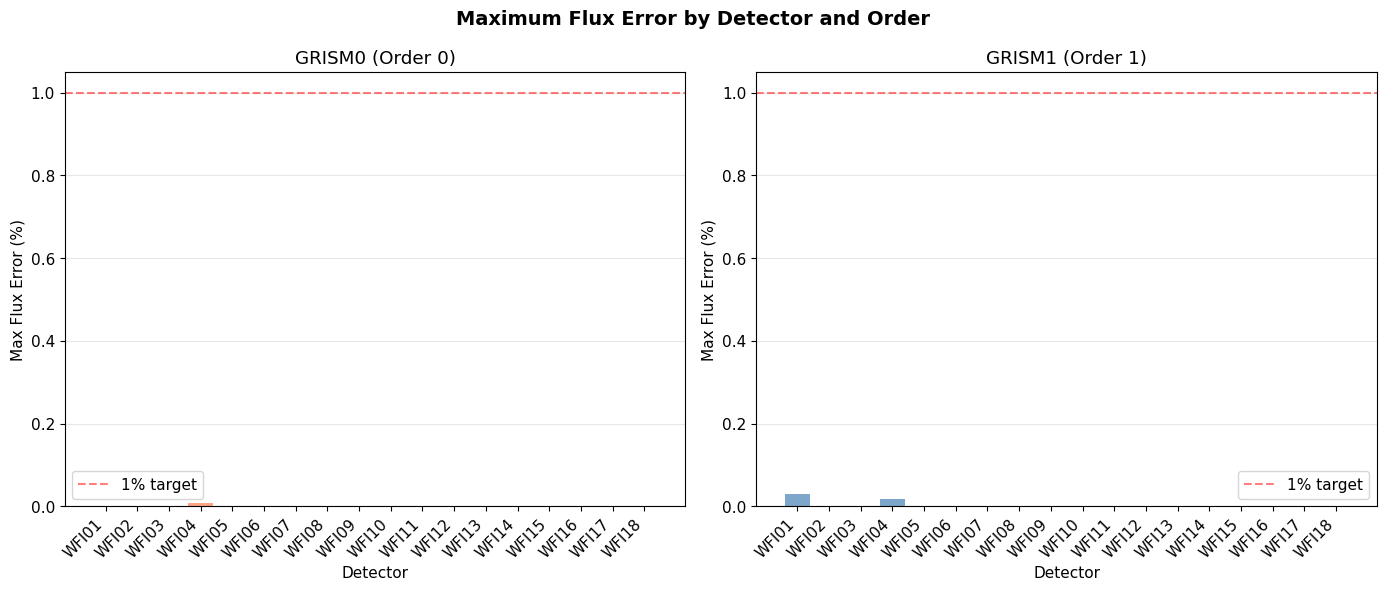

In [9]:
# Heatmap of max flux error by detector and order
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, order in enumerate(ORDERS):
    ax = axes[idx]
    filter_name = 'GRISM0' if order == '0' else 'GRISM1'
    
    # Get data for this order
    order_df = df[df['order'] == order].copy()
    
    # Bar plot
    x = range(len(order_df))
    bars = ax.bar(x, order_df['max_flux_error_pct'], 
                  color='steelblue' if order == '1' else 'coral', alpha=0.7)
    
    ax.set_xticks(x)
    ax.set_xticklabels(order_df['detector'], rotation=45, ha='right')
    ax.set_xlabel('Detector')
    ax.set_ylabel('Max Flux Error (%)')
    ax.set_title(f'{filter_name} (Order {order})')
    ax.grid(alpha=0.3, axis='y')
    
    # Add target line
    ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.5, label='1% target')
    ax.legend()

plt.suptitle('Maximum Flux Error by Detector and Order', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

/var/folders/5s/z32x1yyd4wd7q51zc60yx_0c0000gn/T/ipykernel_98915/1516259517.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_order, labels=labels, patch_artist=True)


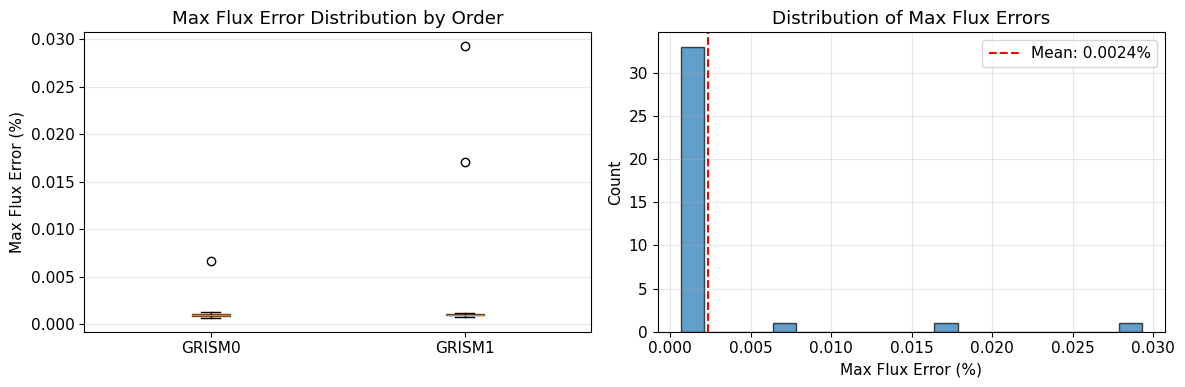

In [10]:
# Distribution of flux errors across all detector/order combinations
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Box plot by order
ax = axes[0]
data_by_order = [df[df['order'] == o]['max_flux_error_pct'].values for o in ORDERS]
labels = ['GRISM0', 'GRISM1']
bp = ax.boxplot(data_by_order, labels=labels, patch_artist=True)
bp['boxes'][0].set_facecolor('coral')
bp['boxes'][1].set_facecolor('steelblue')
for box in bp['boxes']:
    box.set_alpha(0.7)
ax.set_ylabel('Max Flux Error (%)')
ax.set_title('Max Flux Error Distribution by Order')
ax.grid(alpha=0.3, axis='y')

# Histogram of all max errors
ax = axes[1]
ax.hist(df['max_flux_error_pct'], bins=20, edgecolor='black', alpha=0.7)
ax.axvline(df['max_flux_error_pct'].mean(), color='red', linestyle='--',
           label=f"Mean: {df['max_flux_error_pct'].mean():.4f}%")
ax.set_xlabel('Max Flux Error (%)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Max Flux Errors')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

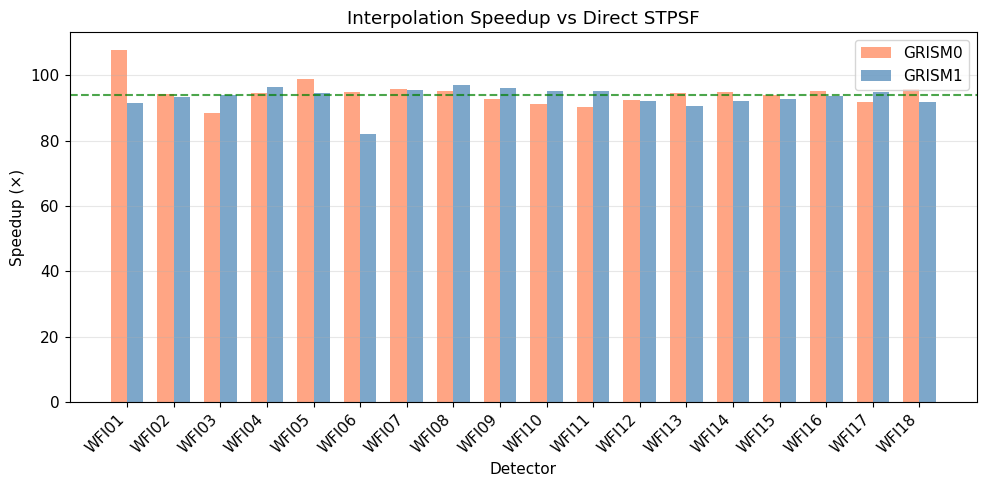

In [11]:
# Speedup comparison
fig, ax = plt.subplots(figsize=(10, 5))

# Group by detector, show both orders
width = 0.35
x = np.arange(len(DETECTORS))

speedups_0 = df[df['order'] == '0']['speedup'].values
speedups_1 = df[df['order'] == '1']['speedup'].values

bars1 = ax.bar(x - width/2, speedups_0, width, label='GRISM0', color='coral', alpha=0.7)
bars2 = ax.bar(x + width/2, speedups_1, width, label='GRISM1', color='steelblue', alpha=0.7)

ax.set_xticks(x)
ax.set_xticklabels(DETECTORS, rotation=45, ha='right')
ax.set_xlabel('Detector')
ax.set_ylabel('Speedup (×)')
ax.set_title('Interpolation Speedup vs Direct STPSF')
ax.legend()
ax.grid(alpha=0.3, axis='y')

# Add mean speedup line
mean_speedup = df['speedup'].mean()
ax.axhline(y=mean_speedup, color='green', linestyle='--', alpha=0.7,
           label=f'Mean: {mean_speedup:.0f}×')

plt.tight_layout()
plt.show()

## Summary Statistics by Order

In [12]:
# Summary by order
print("Summary by Order")
print("="*60)

for order in ORDERS:
    filter_name = 'GRISM0' if order == '0' else 'GRISM1'
    order_df = df[df['order'] == order]
    
    print(f"\n{filter_name} (Order {order}):")
    print(f"  Detectors validated: {len(order_df)}")
    print(f"  Mean flux error:     {order_df['mean_flux_error_pct'].mean():.4f}%")
    print(f"  Max flux error:      {order_df['max_flux_error_pct'].max():.4f}%")
    print(f"  Min flux error:      {order_df['max_flux_error_pct'].min():.4f}%")
    print(f"  Mean speedup:        {order_df['speedup'].mean():.0f}×")

Summary by Order

GRISM0 (Order 0):
  Detectors validated: 18
  Mean flux error:     0.0003%
  Max flux error:      0.0067%
  Min flux error:      0.0007%
  Mean speedup:        95×

GRISM1 (Order 1):
  Detectors validated: 18
  Mean flux error:     0.0005%
  Max flux error:      0.0293%
  Min flux error:      0.0008%
  Mean speedup:        93×


## Final Assessment

In [13]:
# Final pass/fail assessment
TARGET_ERROR = 1.0  # 1% maximum flux error target

max_error_overall = df['max_flux_error_pct'].max()
passed = max_error_overall < TARGET_ERROR

print("="*60)
print("FINAL ASSESSMENT")
print("="*60)
print()
print(f"Target: <{TARGET_ERROR}% maximum flux error")
print(f"Result: {max_error_overall:.4f}% maximum flux error")
print()

if passed:
    print("STATUS: PASSED")
    print("\nAll 18 detectors × 2 orders meet the <1% flux error target.")
    print("PSF interpolation is validated for full-field star dispersion.")
else:
    print("STATUS: FAILED")
    print("\nSome configurations exceed the 1% flux error target.")
    # Show failures
    failures = df[df['max_flux_error_pct'] >= TARGET_ERROR]
    print(f"\nFailures ({len(failures)}):")
    for _, row in failures.iterrows():
        print(f"  {row['detector']} {row['filter']}: {row['max_flux_error_pct']:.4f}%")

print()
print(f"Performance: {df['speedup'].mean():.0f}× faster than direct STPSF")
print(f"Memory: ~121 MB per detector/order payload")
print(f"Total cache size: ~4.4 GB for all 36 payloads")

FINAL ASSESSMENT

Target: <1.0% maximum flux error
Result: 0.0293% maximum flux error

STATUS: PASSED

All 18 detectors × 2 orders meet the <1% flux error target.
PSF interpolation is validated for full-field star dispersion.

Performance: 94× faster than direct STPSF
Memory: ~121 MB per detector/order payload
Total cache size: ~4.4 GB for all 36 payloads


In [14]:
# Save results to CSV for reference
output_file = Path('../../data/psf_validation_results.csv')
df.to_csv(output_file, index=False)
print(f"Results saved to: {output_file.resolve()}")

Results saved to: /Users/npadmana/10-Notebook/1-Projects/roman_disperser/data/psf_validation_results.csv


---

## Radial PSF Error Analysis

The total flux error validates overall normalization, but we also need to verify that
the PSF **shape** is accurately reproduced at all radii.

**Metric**: Fractional error = MAE / PSF value per radial bin  
**Target**: <10% at all radii up to 2.0"

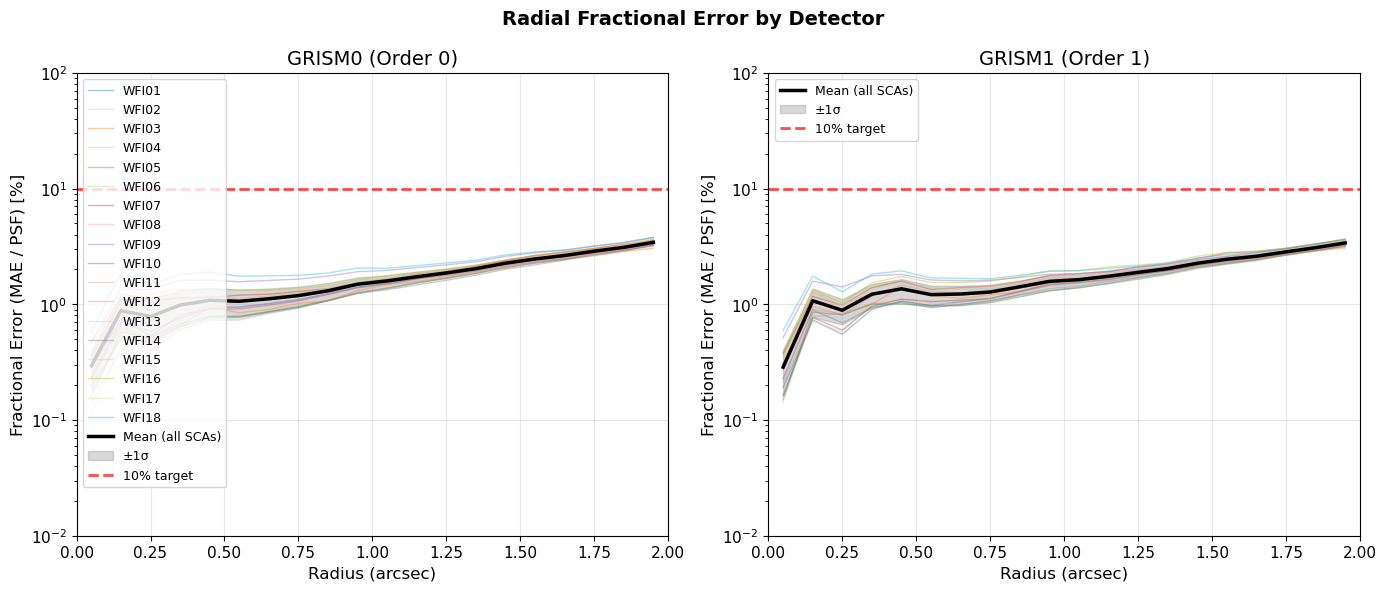

In [15]:
# Plot radial fractional error for all SCAs - one plot per order
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Color map for detectors
cmap = plt.cm.tab20
colors = [cmap(i / len(DETECTORS)) for i in range(len(DETECTORS))]

for idx, order in enumerate(ORDERS):
    ax = axes[idx]
    filter_name = 'GRISM0' if order == '0' else 'GRISM1'
    
    all_frac_errors = []
    
    for det_idx, detector in enumerate(DETECTORS):
        key = (detector, order)
        if key not in radial_results:
            continue
            
        results = radial_results[key]
        bin_edges = results['bin_edges']
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        
        mean_mae = results['mean_mae_per_bin']
        mean_psf = results['mean_psf_per_bin']
        
        # Fractional error (avoid division by zero)
        threshold = 1e-10
        frac_error = np.where(mean_psf > threshold, mean_mae / mean_psf, np.nan)
        all_frac_errors.append(frac_error)
        
        # Plot individual detector with transparency
        ax.plot(bin_centers, frac_error * 100, '-', color=colors[det_idx], 
                alpha=0.4, linewidth=1, label=detector if idx == 0 else None)
    
    # Compute and plot mean across all detectors
    all_frac_errors = np.array(all_frac_errors)
    mean_frac_error = np.nanmean(all_frac_errors, axis=0)
    std_frac_error = np.nanstd(all_frac_errors, axis=0)
    
    ax.plot(bin_centers, mean_frac_error * 100, 'k-', linewidth=2.5, label='Mean (all SCAs)')
    ax.fill_between(bin_centers, 
                    (mean_frac_error - std_frac_error) * 100,
                    (mean_frac_error + std_frac_error) * 100,
                    color='gray', alpha=0.3, label='±1σ')
    
    # Add 10% target line
    ax.axhline(y=10, color='red', linestyle='--', linewidth=2, alpha=0.7, label='10% target')
    
    ax.set_xlabel('Radius (arcsec)', fontsize=12)
    ax.set_ylabel('Fractional Error (MAE / PSF) [%]', fontsize=12)
    ax.set_title(f'{filter_name} (Order {order})', fontsize=14)
    ax.set_yscale('log')
    ax.set_ylim(0.01, 100)
    ax.set_xlim(0, RADIAL_MAX)
    ax.grid(alpha=0.3)
    ax.legend(loc='upper left', fontsize=9)

plt.suptitle('Radial Fractional Error by Detector', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
# Summary statistics for radial fractional error
print("Radial Fractional Error Summary")
print("="*60)

RADIAL_TARGET = 10.0  # 10% maximum fractional error target

for order in ORDERS:
    filter_name = 'GRISM0' if order == '0' else 'GRISM1'
    
    max_frac_errors = []
    
    for detector in DETECTORS:
        key = (detector, order)
        if key not in radial_results:
            continue
        
        results = radial_results[key]
        mean_mae = results['mean_mae_per_bin']
        mean_psf = results['mean_psf_per_bin']
        
        # Fractional error
        threshold = 1e-10
        frac_error = np.where(mean_psf > threshold, mean_mae / mean_psf * 100, 0)
        max_frac_errors.append((detector, frac_error.max()))
    
    max_frac_errors.sort(key=lambda x: x[1], reverse=True)
    
    print(f"\n{filter_name} (Order {order}):")
    print(f"  Max fractional error across all SCAs: {max_frac_errors[0][1]:.2f}%")
    print(f"  Min fractional error across all SCAs: {max_frac_errors[-1][1]:.2f}%")
    print(f"  Worst 3 detectors:")
    for det, err in max_frac_errors[:3]:
        status = "PASS" if err < RADIAL_TARGET else "FAIL"
        print(f"    {det}: {err:.2f}% [{status}]")

Radial Fractional Error Summary

GRISM0 (Order 0):
  Max fractional error across all SCAs: 3.79%
  Min fractional error across all SCAs: 3.05%
  Worst 3 detectors:
    WFI18: 3.79% [PASS]
    WFI09: 3.78% [PASS]
    WFI04: 3.71% [PASS]

GRISM1 (Order 1):
  Max fractional error across all SCAs: 3.67%
  Min fractional error across all SCAs: 3.06%
  Worst 3 detectors:
    WFI04: 3.67% [PASS]
    WFI18: 3.66% [PASS]
    WFI09: 3.66% [PASS]


In [17]:
# Final radial assessment
print("="*60)
print("RADIAL ERROR ASSESSMENT")
print("="*60)

# Collect all max fractional errors
all_max_frac_errors = []
for (detector, order), results in radial_results.items():
    mean_mae = results['mean_mae_per_bin']
    mean_psf = results['mean_psf_per_bin']
    threshold = 1e-10
    frac_error = np.where(mean_psf > threshold, mean_mae / mean_psf * 100, 0)
    all_max_frac_errors.append(frac_error.max())

overall_max_radial = max(all_max_frac_errors)
radial_passed = overall_max_radial < RADIAL_TARGET

print()
print(f"Target: <{RADIAL_TARGET}% fractional error at all radii")
print(f"Result: {overall_max_radial:.2f}% maximum fractional error")
print()

if radial_passed:
    print("STATUS: PASSED")
    print("\nAll 18 detectors × 2 orders meet the <10% radial fractional error target.")
else:
    print("STATUS: FAILED")
    # Find failures
    failures = []
    for (detector, order), results in radial_results.items():
        mean_mae = results['mean_mae_per_bin']
        mean_psf = results['mean_psf_per_bin']
        frac_error = np.where(mean_psf > 1e-10, mean_mae / mean_psf * 100, 0)
        if frac_error.max() >= RADIAL_TARGET:
            failures.append((detector, order, frac_error.max()))
    print(f"\nFailures ({len(failures)}):")
    for det, order, err in failures:
        filter_name = 'GRISM0' if order == '0' else 'GRISM1'
        print(f"  {det} {filter_name}: {err:.2f}%")

print()
print("="*60)
print("COMBINED ASSESSMENT")
print("="*60)
print()
print(f"Total Flux Error:     {'PASSED' if passed else 'FAILED'} (max {max_error_overall:.4f}% < 1%)")
print(f"Radial Shape Error:   {'PASSED' if radial_passed else 'FAILED'} (max {overall_max_radial:.2f}% < 10%)")
print()
if passed and radial_passed:
    print("OVERALL STATUS: PASSED")
    print("\nPSF interpolation validated for both flux conservation and shape accuracy.")
else:
    print("OVERALL STATUS: FAILED")
    print("\nSome validation criteria not met. Review failures above.")

RADIAL ERROR ASSESSMENT

Target: <10.0% fractional error at all radii
Result: 3.79% maximum fractional error

STATUS: PASSED

All 18 detectors × 2 orders meet the <10% radial fractional error target.

COMBINED ASSESSMENT

Total Flux Error:     PASSED (max 0.0293% < 1%)
Radial Shape Error:   PASSED (max 3.79% < 10%)

OVERALL STATUS: PASSED

PSF interpolation validated for both flux conservation and shape accuracy.


In [18]:
# Save radial results for future analysis (optional)
import pickle

radial_output_file = Path('../../data/psf_radial_validation.pkl')
with open(radial_output_file, 'wb') as f:
    pickle.dump({
        'radial_results': radial_results,
        'config': {
            'radial_bin_size': RADIAL_BIN_SIZE,
            'radial_max': RADIAL_MAX,
            'n_test_points': N_TEST_POINTS,
            'pixel_scale': PIXEL_SCALE,
        }
    }, f)
print(f"Radial results saved to: {radial_output_file.resolve()}")

Radial results saved to: /Users/npadmana/10-Notebook/1-Projects/roman_disperser/data/psf_radial_validation.pkl
